In [24]:
#Part 1 data load

In [121]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")



In [123]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

2. Load Dataset

In [126]:
dataset = pd.read_excel("sample_store.xls")

In [128]:
df = dataset.copy()

3. First Look at the Dataset

In [131]:
df.shape

(10194, 21)

In [133]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2021-103800,2021-01-03,2021-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2021-112326,2021-01-04,2021-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2021-112326,2021-01-04,2021-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2021-112326,2021-01-04,2021-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2021-141817,2021-01-05,2021-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [135]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
10189,10190,US-2024-143259,2024-12-30,2025-01-03,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,New York,10009,East,OFF-BI-10003684,Office Supplies,Binders,Wilson Jones Legal Size Ring Binders,52.776,3,0.2,19.7910
10190,10191,US-2024-115427,2024-12-30,2025-01-03,Standard Class,EB-13975,Erica Bern,Corporate,United States,Fairfield,California,94533,West,OFF-BI-10004632,Office Supplies,Binders,GBC Binding covers,20.720,2,0.2,6.4750
10191,10192,US-2024-156720,2024-12-30,2025-01-03,Standard Class,JM-15580,Jill Matthias,Consumer,United States,Loveland,Colorado,80538,West,OFF-FA-10003472,Office Supplies,Fasteners,Bagged Rubber Bands,3.024,3,0.2,-0.6048
10192,10193,US-2024-143259,2024-12-30,2025-01-03,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,New York,10009,East,TEC-PH-10004774,Technology,Phones,Gear Head AU3700S Headset,90.930,7,0.0,2.7279
10193,10194,CA-2024-143500,2024-12-30,2025-01-03,Standard Class,HO-15230,Harry Olson,Consumer,Canada,Charlottetown,Prince Edward Island,C0A,East,OFF-BI-10004040,Office Supplies,Binders,Wilson Jones Impact Binders,3.024,3,0.2,-0.6048


In [137]:
df.sample(10, random_state=42)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
6636,6637,US-2023-108777,2023-12-12,2023-12-12,Same Day,JM-15655,Jim Mitchum,Corporate,United States,Lorain,Ohio,44052,East,OFF-BI-10003982,Office Supplies,Binders,Wilson Jones Century Plastic Molded Ring Binders,18.693,3,0.7,-14.3313
3742,3743,US-2022-102778,2022-11-21,2022-11-24,First Class,JH-15820,John Huston,Consumer,United States,Monroe,North Carolina,28110,South,FUR-FU-10000087,Furniture,Furnishings,"Executive Impressions 14"" Two-Color Numerals W...",18.176,1,0.2,4.7712
5114,5115,US-2023-153577,2023-06-27,2023-07-01,Standard Class,KH-16330,Katharine Harms,Corporate,United States,Highland Park,Illinois,60035,Central,FUR-CH-10003981,Furniture,Chairs,Global Commerce Series Low-Back Swivel/Tilt Ch...,539.658,3,0.3,-7.7094
6505,6506,US-2023-161025,2023-12-03,2023-12-09,Standard Class,GM-14440,Gary McGarr,Consumer,United States,Los Angeles,California,90049,West,OFF-ST-10001932,Office Supplies,Storage,Fellowes Staxonsteel Drawer Files,772.680,4,0.0,108.1752
10072,10073,US-2024-155376,2024-12-22,2024-12-27,Standard Class,SG-20080,Sandra Glassco,Consumer,United States,Independence,Missouri,64055,Central,OFF-AP-10001058,Office Supplies,Appliances,Sanyo 2.5 Cubic Foot Mid-Size Office Refrigera...,839.430,3,0.0,218.2518
6520,6521,US-2023-114489,2023-12-05,2023-12-09,Standard Class,JE-16165,Justin Ellison,Corporate,United States,Franklin,Wisconsin,53132,Central,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",1951.840,8,0.0,585.5520
3149,3150,US-2022-165057,2022-09-11,2022-09-15,Standard Class,SC-20725,Steven Cartwright,Consumer,United States,Redlands,California,92374,West,OFF-AR-10004648,Office Supplies,Art,Boston 19500 Mighty Mite Electric Pencil Sharp...,181.350,9,0.0,48.9645
2876,2877,US-2022-120810,2022-07-23,2022-07-27,Standard Class,TH-21550,Tracy Hopkins,Home Office,United States,New York City,New York,10009,East,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,68.940,3,0.0,20.6820
5610,5611,US-2023-151372,2023-09-05,2023-09-06,First Class,JH-15985,Joseph Holt,Consumer,United States,Redondo Beach,California,90278,West,OFF-FA-10000304,Office Supplies,Fasteners,Advantus Push Pins,4.360,2,0.0,1.7876
7742,7743,US-2024-132297,2024-05-27,2024-06-02,Standard Class,DW-13480,Dianna Wilson,Home Office,United States,Louisville,Kentucky,40214,South,OFF-BI-10003364,Office Supplies,Binders,Binding Machine Supplies,58.340,2,0.0,28.0032


4. Understand the Data Types

In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  object        
 2   Order Date      10194 non-null  datetime64[ns]
 3   Ship Date       10194 non-null  datetime64[ns]
 4   Ship Mode       10194 non-null  object        
 5   Customer ID     10194 non-null  object        
 6   Customer Name   10194 non-null  object        
 7   Segment         10194 non-null  object        
 8   Country/Region  10194 non-null  object        
 9   City            10194 non-null  object        
 10  State/Province  10194 non-null  object        
 11  Postal Code     10194 non-null  object        
 12  Region          10194 non-null  object        
 13  Product ID      10194 non-null  object        
 14  Category        10194 non-null  object        
 15  Su

5. Dataset Description

In [143]:
data_dictionary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values
})

data_dictionary

,Column,Data Type,Missing Values,Unique Values
Row ID,Row ID,int64,0,10194
Order ID,Order ID,object,0,5111
Order Date,Order Date,datetime64[ns],0,1242
Ship Date,Ship Date,datetime64[ns],0,1338
Ship Mode,Ship Mode,object,0,4
Customer ID,Customer ID,object,0,804
Customer Name,Customer Name,object,0,800
Segment,Segment,object,0,3
Country/Region,Country/Region,object,0,2
City,City,object,0,542


6. Missing Value Analysis

In [146]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [148]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": df.isnull().mean() * 100
})

missing.sort_values(
    "Missing Percentage",
    ascending=False
)

,Missing Count,Missing Percentage
Row ID,0,0.0
Postal Code,0,0.0
Discount,0,0.0
Quantity,0,0.0
Sales,0,0.0
Product Name,0,0.0
Sub-Category,0,0.0
Category,0,0.0
Product ID,0,0.0
Region,0,0.0


7. Duplicate Analysis

In [153]:
df.duplicated().sum()

0

8. Check Each Categorical Variable

In [156]:
categorical_columns = df.select_dtypes(
    include="object"
).columns

for col in categorical_columns:
    print("\n" + "=" * 50)
    print(col)
    print("Unique values:", df[col].nunique())
    print(df[col].unique()[:20])


Order ID
Unique values: 5111
['US-2021-103800' 'US-2021-112326' 'US-2021-141817' 'US-2021-167199'
 'US-2021-106054' 'US-2021-130813' 'US-2021-105417' 'US-2021-135405'
 'US-2021-149020' 'US-2021-130092' 'US-2021-157147' 'US-2021-109232'
 'US-2021-118192' 'US-2021-162775' 'US-2021-149524' 'US-2021-103366'
 'US-2021-115791' 'US-2021-123477' 'US-2021-146591' 'US-2021-147627']

Ship Mode
Unique values: 4
['Standard Class' 'First Class' 'Second Class' 'Same Day']

Customer ID
Unique values: 804
['DP-13000' 'PO-19195' 'MB-18085' 'ME-17320' 'JO-15145' 'LS-17230'
 'VS-21820' 'MS-17830' 'AJ-10780' 'SV-20365' 'BD-11605' 'ND-18370'
 'MM-17920' 'CS-12250' 'BS-11590' 'EH-13990' 'DL-13315' 'DW-13195'
 'TS-21340' 'HL-15040']

Customer Name
Unique values: 800
['Darren Powers' 'Phillina Ober' 'Mick Brown' 'Maria Etezadi'
 "Jack O'Briant" 'Lycoris Saunders' 'Vivek Sundaresam' 'Melanie Seite'
 'Anthony Jacobs' 'Seth Vernon' 'Brian Dahlen' 'Natalie DeCherney'
 'Michael Moore' 'Chris Selesnick' 'Brendan Sw

9. Numerical Summary

In [159]:
df.describe()

,Row ID,Order Date,Ship Date,Sales,Quantity,Discount,Profit
count,10194.000000,10194,10194,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,2023-04-30 00:15:40.788699136,2023-05-03 23:20:43.790465024,228.225854,3.791838,0.155385,28.673417
min,1.000000,2021-01-03 00:00:00,2021-01-07 00:00:00,0.444000,1.000000,0.000000,-6599.978000
25%,2549.250000,2022-05-14 00:00:00,2022-05-19 00:00:00,17.220000,2.000000,0.000000,1.760800
50%,5097.500000,2023-06-25 00:00:00,2023-06-28 00:00:00,53.910000,3.000000,0.200000,8.690000
75%,7645.750000,2024-05-14 00:00:00,2024-05-18 00:00:00,209.500000,5.000000,0.200000,29.297925
max,10194.000000,2024-12-30 00:00:00,2025-01-05 00:00:00,22638.480000,14.000000,0.800000,8399.976000
std,2942.898656,NaN,NaN,619.906839,2.228317,0.206249,232.465115


In [161]:
numeric_columns = [
    "Sales",
    "Quantity",
    "Discount",
    "Profit"
]

df[numeric_columns].describe()

,Sales,Quantity,Discount,Profit
count,10194.000000,10194.000000,10194.000000,10194.000000
mean,228.225854,3.791838,0.155385,28.673417
std,619.906839,2.228317,0.206249,232.465115
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.220000,2.000000,0.000000,1.760800
50%,53.910000,3.000000,0.200000,8.690000
75%,209.500000,5.000000,0.200000,29.297925
max,22638.480000,14.000000,0.800000,8399.976000


10. Statistical Properties

In [164]:
df[numeric_columns].mean()

Sales       228.225854
Quantity      3.791838
Discount      0.155385
Profit       28.673417
dtype: float64

In [166]:
df[numeric_columns].median()

Sales       53.91
Quantity     3.00
Discount     0.20
Profit       8.69
dtype: float64

In [168]:
df[numeric_columns].std()

Sales       619.906839
Quantity      2.228317
Discount      0.206249
Profit      232.465115
dtype: float64

In [170]:
df[numeric_columns].skew()

Sales       12.983926
Quantity     1.268633
Discount     1.687453
Profit       7.604906
dtype: float64

In [172]:
df[numeric_columns].kurtosis()

Sales       306.366270
Quantity      1.961526
Discount      2.416291
Profit      401.692916
dtype: float64

11. Date Validation

In [175]:
df["Order Date"].min()

Timestamp('2021-01-03 00:00:00')

In [177]:
df["Order Date"].max()

Timestamp('2024-12-30 00:00:00')

In [179]:
df["Ship Date"].min()

Timestamp('2021-01-07 00:00:00')

In [181]:
df["Ship Date"].max()

Timestamp('2025-01-05 00:00:00')

In [183]:
(df["Ship Date"] < df["Order Date"]).sum()

0

12. Feature Engineering

In [186]:
df["Order Year"] = df["Order Date"].dt.year

df["Order Month"] = df["Order Date"].dt.month

df["Order Month Name"] = df["Order Date"].dt.month_name()

df["Order Quarter"] = df["Order Date"].dt.quarter

df["Day of Week"] = df["Order Date"].dt.day_name()

In [188]:
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

In [190]:
df["Shipping Days"].describe()

count    10194.000000
mean         3.961840
std          1.744106
min          0.000000
25%          3.000000
50%          4.000000
75%          5.000000
max         11.000000
Name: Shipping Days, dtype: float64

13. Business KPIs

In [193]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_quantity = df["Quantity"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()

In [195]:
profit_margin = (
    total_profit / total_sales
) * 100

In [197]:
print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Quantity:", total_quantity)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Overall Profit Margin:", profit_margin)

Total Sales: 2326534.3543
Total Profit: 292296.8145999999
Total Quantity: 38654
Total Orders: 5111
Total Customers: 804
Overall Profit Margin: 12.563614805849074


14. Sales Distribution

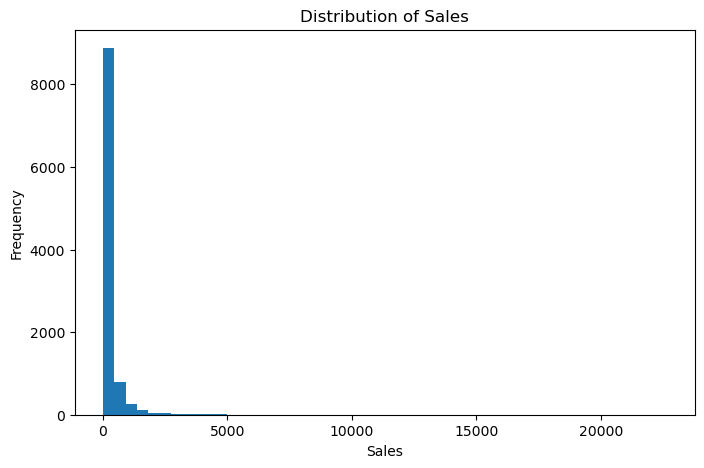

In [200]:
plt.figure(figsize=(8,5))

plt.hist(df["Sales"], bins=50)

plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.title("Distribution of Sales")

plt.show()

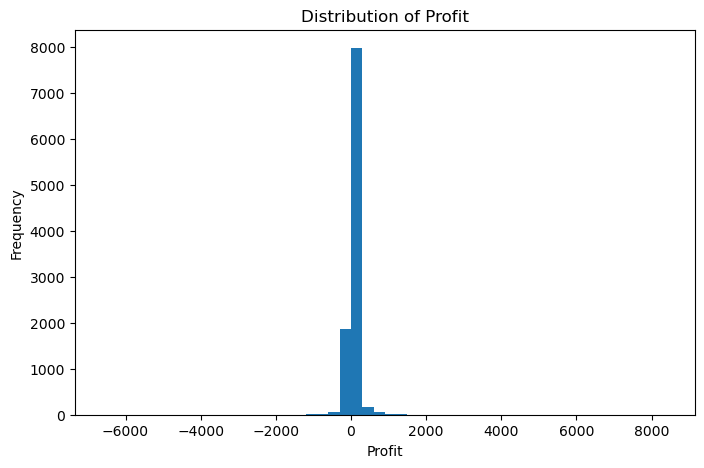

In [202]:
plt.figure(figsize=(8,5))

plt.hist(df["Profit"], bins=50)

plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.title("Distribution of Profit")

plt.show()

15. Outlier Detection

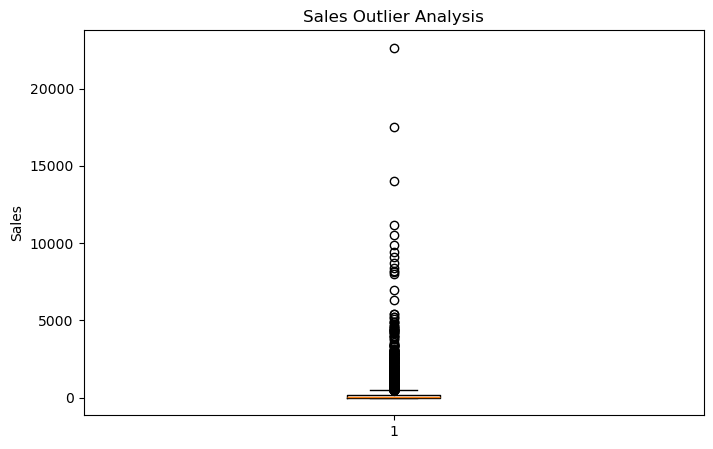

In [205]:
plt.figure(figsize=(8,5))

plt.boxplot(df["Sales"])

plt.ylabel("Sales")
plt.title("Sales Outlier Analysis")

plt.show()

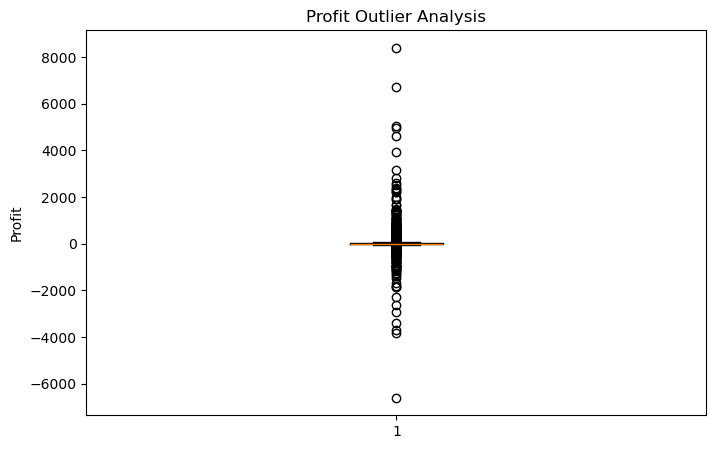

In [207]:
plt.figure(figsize=(8,5))

plt.boxplot(df["Profit"])

plt.ylabel("Profit")
plt.title("Profit Outlier Analysis")

plt.show()

In [209]:
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

sales_outliers = df[
    (df["Sales"] < lower_bound) |
    (df["Sales"] > upper_bound)
]

print("Number of Sales outliers:", len(sales_outliers))

Number of Sales outliers: 1183


16. Category Analysis

In [212]:
category_analysis = df.groupby("Category").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum"),
    Orders=("Order ID", "nunique")
)

category_analysis["Profit Margin (%)"] = (
    category_analysis["Profit"] /
    category_analysis["Sales"]
) * 100

category_analysis.sort_values(
    "Profit",
    ascending=False
)

,Sales,Profit,Quantity,Orders,Profit Margin (%)
Category,,,,,
Technology,839893.2790,146543.3756,7017,1560,17.447857
Office Supplies,731893.3140,126023.4434,23268,3812,17.218827
Furniture,754747.7613,19729.9956,8369,1819,2.614118


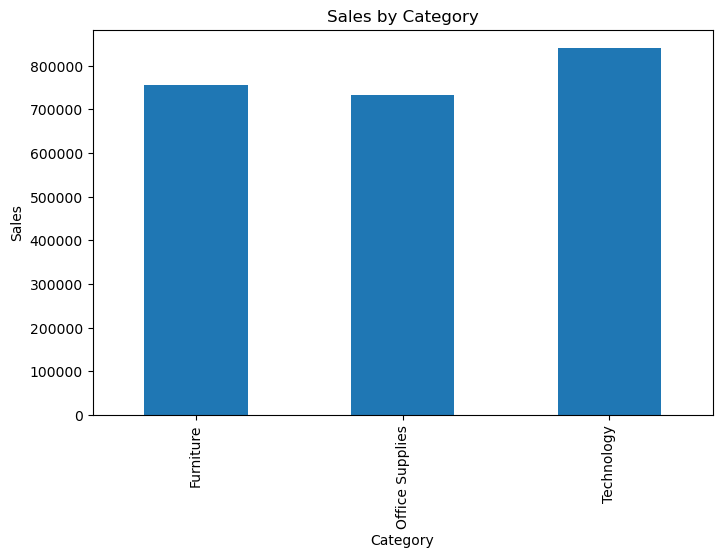

In [214]:
category_analysis["Sales"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Sales by Category")
plt.ylabel("Sales")
plt.xlabel("Category")

plt.show()

17. Sub-Category Analysis

In [217]:
subcategory_analysis = df.groupby(
    "Sub-Category"
).agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum"),
    Orders=("Order ID", "nunique")
)

subcategory_analysis["Profit Margin (%)"] = (
    subcategory_analysis["Profit"] /
    subcategory_analysis["Sales"]
) * 100

In [219]:
subcategory_analysis.sort_values(
    "Profit",
    ascending=False
).head(10)

,Sales,Profit,Quantity,Orders,Profit Margin (%)
Sub-Category,,,,,
Copiers,150745.290,56093.9365,242,70,37.211071
Phones,331842.640,45050.8265,3357,826,13.575961
Accessories,167380.318,41936.6357,2976,718,25.054700
Paper,79540.538,34511.5070,5207,1205,43.388576
Binders,207354.881,31426.1003,6071,1339,15.155708
Chairs,335768.249,27223.5323,2431,591,8.107834
Storage,224644.554,21285.1115,3191,787,9.475018
Appliances,108213.185,18329.4844,1750,459,16.938310
Furnishings,95598.126,13891.7430,3799,919,14.531397


In [221]:
subcategory_analysis.sort_values(
    "Profit",
    ascending=True
).head(10)

,Sales,Profit,Quantity,Orders,Profit Margin (%)
Sub-Category,,,,,
Tables,208020.1820,-17753.2061,1261,314,-8.534367
Bookcases,115361.2043,-3632.0736,878,228,-3.148436
Supplies,46725.4980,-1171.3945,653,189,-2.506971
Fasteners,8532.2400,2428.6358,980,226,28.464223
Machines,189925.0310,3461.9769,442,114,1.822812
Labels,12695.0420,5572.7780,1410,348,43.897279
Art,27659.0140,6653.1962,3092,756,24.054351
Envelopes,16528.3620,6988.0247,914,251,42.278991
Furnishings,95598.1260,13891.7430,3799,919,14.531397


18. Region Analysis

In [224]:
region_analysis = df.groupby("Region").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
)

region_analysis["Profit Margin (%)"] = (
    region_analysis["Profit"] /
    region_analysis["Sales"]
) * 100

region_analysis

,Sales,Profit,Quantity,Profit Margin (%)
Region,,,,
Central,503170.6728,39865.3070,8820,7.922820
East,691828.1680,94883.2603,11159,13.714859
South,391721.9050,46749.4303,6209,11.934342
West,739813.6085,110798.8170,12466,14.976585


19. State Analysis

In [229]:
state_analysis = df.groupby(
    "State/Province"
).agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum")
)

state_analysis["Profit Margin (%)"] = (
    state_analysis["Profit"] /
    state_analysis["Sales"]
) * 100

In [231]:
state_analysis.sort_values(
    "Profit",
    ascending=False
).head(10)

,Sales,Profit,Profit Margin (%)
State/Province,,,
California,457687.6315,76381.3871,16.688541
New York,310876.2710,74038.5486,23.816082
Washington,138641.2700,33402.6517,24.092863
Michigan,76269.6140,24463.1876,32.074618
Virginia,70636.7200,18597.9504,26.329012
Indiana,53555.3600,18382.9363,34.325110
Georgia,49095.8400,16250.0433,33.098615
Kentucky,36591.7500,11199.6966,30.607163
Minnesota,29863.1500,10823.1874,36.242618


In [233]:
state_analysis.sort_values(
    "Profit"
).head(10)

,Sales,Profit,Profit Margin (%)
State/Province,,,
Texas,170188.0458,-25729.3563,-15.118192
Ohio,78258.1360,-16971.3766,-21.686405
Pennsylvania,116511.9140,-15559.9603,-13.354823
Illinois,80166.1010,-12607.8870,-15.727205
North Carolina,55603.1640,-7490.9122,-13.472097
Colorado,32108.1180,-6527.8579,-20.330864
Tennessee,30661.8730,-5341.6936,-17.421289
Arizona,35282.0010,-3427.9246,-9.715789
Florida,89473.7080,-3399.3017,-3.799219


20. Segment Analysis

In [236]:
segment_analysis = df.groupby("Segment").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
)

segment_analysis["Profit Margin (%)"] = (
    segment_analysis["Profit"] /
    segment_analysis["Sales"]
) * 100

segment_analysis

,Sales,Profit,Quantity,Profit Margin (%)
Segment,,,,
Consumer,1.170660e+06,136371.4463,19844,11.649110
Corporate,7.158061e+05,94249.6400,11898,13.166923
Home Office,4.400684e+05,61675.7283,6912,14.015031


21. Shipping Analysis

In [239]:
ship_analysis = df.groupby("Ship Mode").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Average_Shipping_Days=("Shipping Days", "mean"),
    Orders=("Order ID", "nunique")
)

ship_analysis

,Sales,Profit,Average_Shipping_Days,Orders
Ship Mode,,,,
First Class,3.517507e+05,49012.7242,2.182171,795
Same Day,1.292720e+05,16160.7480,0.043876,266
Second Class,4.666711e+05,58962.1329,3.237494,982
Standard Class,1.378841e+06,168161.2095,4.996405,3068


22. Customer Analysis

In [242]:
customer_analysis = df.groupby(
    ["Customer ID", "Customer Name"]
).agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Orders=("Order ID", "nunique"),
    Quantity=("Quantity", "sum")
)

In [244]:
customer_analysis.sort_values(
    "Sales",
    ascending=False
).head(10)

,,Sales,Profit,Orders,Quantity
Customer ID,Customer Name,,,,
SM-20320,Sean Miller,25043.050,-1980.7393,5,50
TC-20980,Tamara Chand,19052.218,8981.3239,5,42
RB-19360,Raymond Buch,15117.339,6976.0959,6,71
TA-21385,Tom Ashbrook,14595.620,4703.7883,4,36
AB-10105,Adrian Barton,14473.571,5444.8055,10,73
KL-16645,Ken Lonsdale,14175.229,806.8550,12,113
SC-20095,Sanjit Chand,14142.334,5757.4119,9,87
HL-15040,Hunter Lopez,12873.298,5622.4292,6,50
SE-20110,Sanjit Engle,12209.438,2650.6769,11,78


In [246]:
customer_analysis.sort_values(
    "Profit",
    ascending=False
).head(10)

,,Sales,Profit,Orders,Quantity
Customer ID,Customer Name,,,,
TC-20980,Tamara Chand,19052.218,8981.3239,5,42
RB-19360,Raymond Buch,15117.339,6976.0959,6,71
SC-20095,Sanjit Chand,14142.334,5757.4119,9,87
HL-15040,Hunter Lopez,12873.298,5622.4292,6,50
AB-10105,Adrian Barton,14473.571,5444.8055,10,73
TA-21385,Tom Ashbrook,14595.620,4703.7883,4,36
CM-12385,Christopher Martinez,8954.020,3899.8904,4,34
KD-16495,Keith Dawkins,8181.256,3038.6254,12,84
AR-10540,Andy Reiter,6608.448,2884.6208,6,33


23. Product Analysis

In [249]:
product_analysis = df.groupby(
    ["Product ID", "Product Name"]
).agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
)

In [251]:
product_analysis.sort_values(
    "Sales",
    ascending=False
).head(10)

,,Sales,Profit,Quantity
Product ID,Product Name,,,
TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,61599.824,2.519993e+04,20
OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384,7.753039e+03,31
TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1.811078e+03,6
FUR-CH-10002024,HON 5400 Series Task Chairs for Big and Tall,21870.576,3.410605e-13,39
OFF-BI-10001359,GBC DocuBind TL300 Electric Binding System,19823.479,2.233505e+03,37
OFF-BI-10000545,GBC Ibimaster 500 Manual ProClick Binding System,19024.500,7.609800e+02,48
TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,18839.686,6.983884e+03,38
TEC-MA-10001127,"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895,4.094977e+03,12
OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,17965.068,-1.878166e+03,27


product_analysis.sort_values(
    "Profit"
).head(10)

24. The High-Sales / Low-Profit Problem

In [256]:
product_analysis[
    (product_analysis["Sales"] >
     product_analysis["Sales"].median()) &
    (product_analysis["Profit"] < 0)
].sort_values(
    "Sales",
    ascending=False
)

,,Sales,Profit,Quantity
Product ID,Product Name,,,
TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1811.0784,6
OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,17965.068,-1878.1662,27
OFF-SU-10000151,High Speed Automatic Electric Letter Opener,17030.312,-262.0048,11
TEC-MA-10000822,Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730,18
OFF-SU-10002881,Martin Yale Chadless Opener Electric Letter Opener,16656.200,-1299.1836,22
...,...,...,...,...
FUR-BO-10003433,Sauder Cornerstone Collection Library,322.192,-81.1676,14
OFF-ST-10000419,"Rogers Jumbo File, Granite",317.772,-4.8888,24
OFF-AP-10004980,3M Replacement Filter for Office Air Cleaner for 20' x 33' Room,303.360,-20.4768,14


25. Discount Analysis

In [260]:
discount_analysis = df.groupby("Discount").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
)

discount_analysis["Profit Margin (%)"] = (
    discount_analysis["Profit"] /
    discount_analysis["Sales"]
) * 100

discount_analysis

,Sales,Profit,Quantity,Profit Margin (%)
Discount,,,,
0.00,1.105324e+06,326718.5872,18770,29.558632
0.10,5.495250e+04,9099.9700,377,16.559702
0.15,2.755852e+04,1418.9915,198,5.149012
0.20,7.739394e+05,91079.9517,13856,11.768357
0.30,1.044741e+05,-10513.4456,855,-10.063211
0.32,1.449346e+04,-2391.1377,105,-16.498047
0.40,1.164978e+05,-23086.3742,789,-19.817012
0.45,5.484974e+03,-2493.1111,45,-45.453472
0.50,5.891854e+04,-20506.4281,241,-34.804712


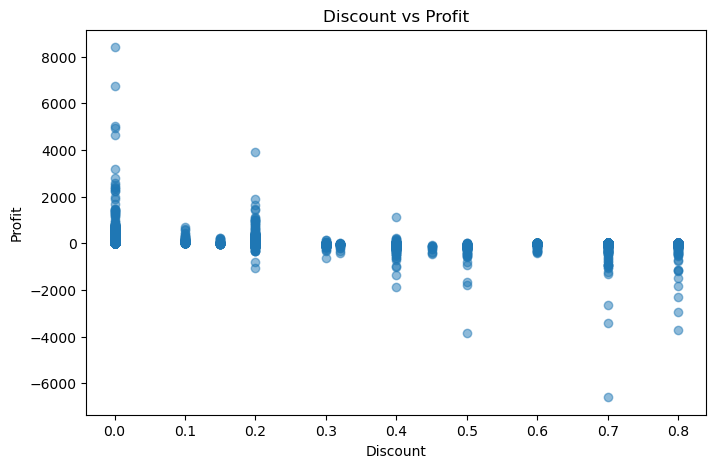

In [262]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Discount"],
    df["Profit"],
    alpha=0.5
)

plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Discount vs Profit")

plt.show()

26. Correlation Analysis

In [265]:
correlation_columns = [
    "Sales",
    "Quantity",
    "Discount",
    "Profit",
    "Shipping Days"
]

correlation = df[
    correlation_columns
].corr()

correlation

,Sales,Quantity,Discount,Profit,Shipping Days
Sales,1.000000,0.198457,-0.027756,0.481460,-0.007056
Quantity,0.198457,1.000000,0.007475,0.066145,0.020852
Discount,-0.027756,0.007475,1.000000,-0.218882,-0.001739
Profit,0.481460,0.066145,-0.218882,1.000000,-0.004358
Shipping Days,-0.007056,0.020852,-0.001739,-0.004358,1.000000


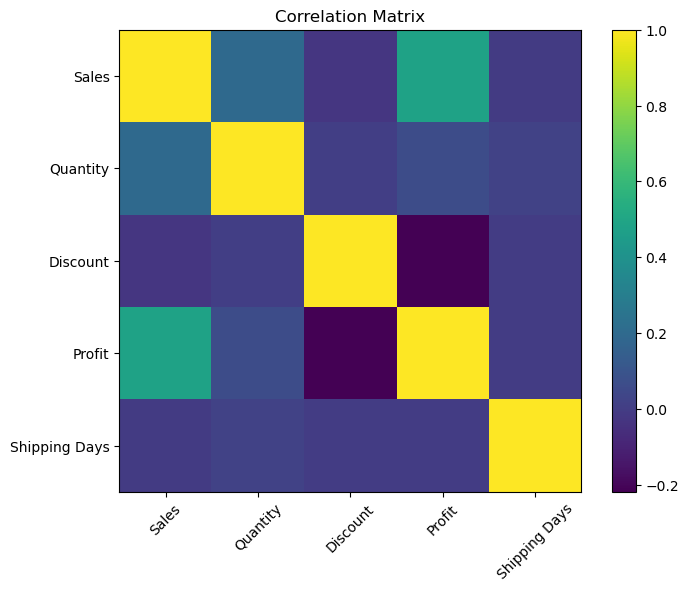

In [267]:
plt.figure(figsize=(8,6))

plt.imshow(correlation)

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.colorbar()

plt.title("Correlation Matrix")

plt.show()

27. Time-Series Analysis

In [270]:
yearly = df.groupby("Order Year").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum")
)

yearly

,Sales,Profit
Order Year,,
2021,494040.2121,51684.2957
2022,472993.0310,62020.9695
2023,613933.5800,82665.2018
2024,745567.5312,95926.3476


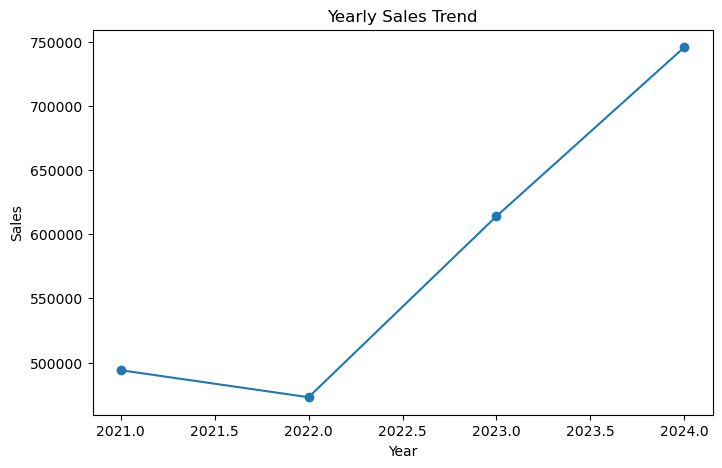

In [272]:
plt.figure(figsize=(8,5))

plt.plot(
    yearly.index,
    yearly["Sales"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Sales")
plt.title("Yearly Sales Trend")

plt.show()

In [274]:
monthly = df.groupby(
    df["Order Date"].dt.to_period("M")
).agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum")
)

In [276]:
monthly.index = monthly.index.to_timestamp()

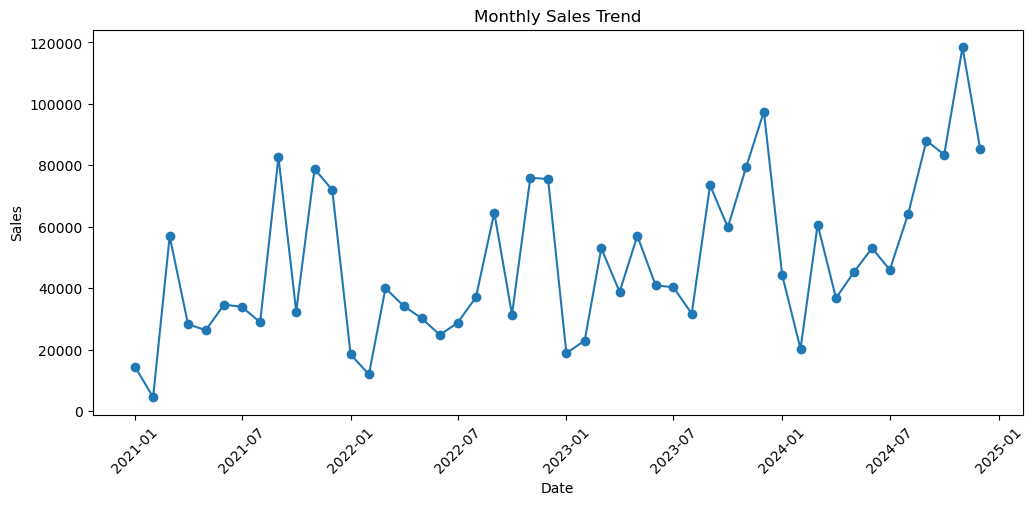

In [278]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly.index,
    monthly["Sales"],
    marker="o"
)

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Monthly Sales Trend")

plt.xticks(rotation=45)

plt.show()

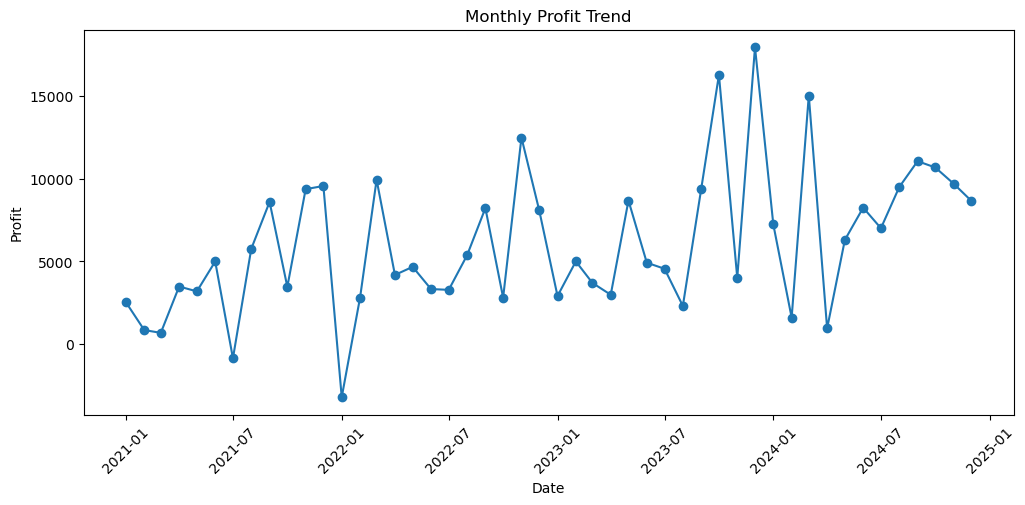

In [280]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly.index,
    monthly["Profit"],
    marker="o"
)

plt.xlabel("Date")
plt.ylabel("Profit")
plt.title("Monthly Profit Trend")

plt.xticks(rotation=45)

plt.show()

28. Sales vs Profit

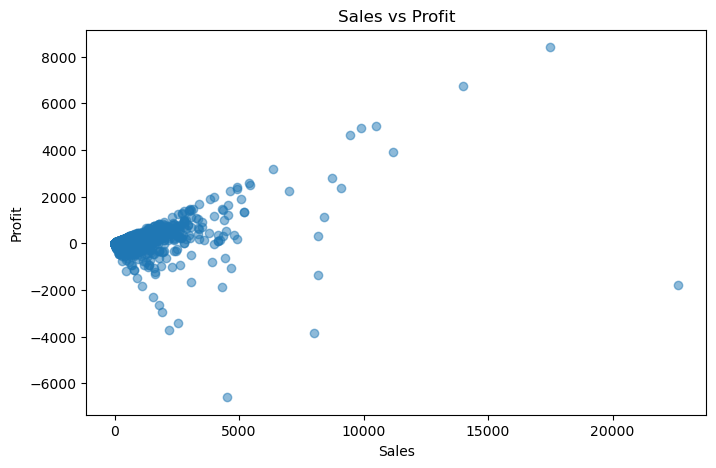

In [283]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Sales"],
    df["Profit"],
    alpha=0.5
)

plt.xlabel("Sales")
plt.ylabel("Profit")
plt.title("Sales vs Profit")

plt.show()

29. Quantity vs Profit

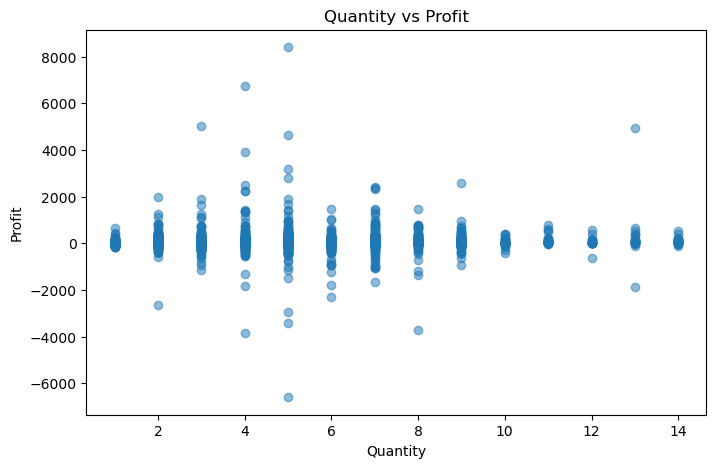

In [286]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Quantity"],
    df["Profit"],
    alpha=0.5
)

plt.xlabel("Quantity")
plt.ylabel("Profit")
plt.title("Quantity vs Profit")

plt.show()

30. Create a Business Insight Table

In [289]:
insight_summary = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Profit",
        "Total Orders",
        "Total Customers",
        "Overall Profit Margin"
    ],
    "Value": [
        total_sales,
        total_profit,
        total_orders,
        total_customers,
        profit_margin
    ]
})

insight_summary

,Metric,Value
0,Total Sales,2.326534e+06
1,Total Profit,2.922968e+05
2,Total Orders,5.111000e+03
3,Total Customers,8.040000e+02
4,Overall Profit Margin,1.256361e+01


31.Prepare ML Dataset

In [292]:
ml_df = df[
    [
        "Sales",
        "Quantity",
        "Discount",
        "Shipping Days",
        "Category",
        "Sub-Category",
        "Region",
        "Segment",
        "Ship Mode",
        "Profit"
    ]
].copy()

32. Separate X and y

In [295]:
X = ml_df.drop("Profit", axis=1)

y = ml_df["Profit"]

33.Identify Numerical and Categorical Features

In [298]:
numeric_features = [
    "Sales",
    "Quantity",
    "Discount",
    "Shipping Days"
]

categorical_features = [
    "Category",
    "Sub-Category",
    "Region",
    "Segment",
    "Ship Mode"
]

34. Preprocessing Pipeline

In [301]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

35.Train/Test Split

In [304]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

34. Linear Regression

In [307]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [309]:
linear_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Sales', 'Quantity',
                                                   'Discount',
                                                   'Shipping Days']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Category', 'Sub-Category',
                                                   'Region', 'Segment',
                                                   'Ship Mode'])])),
                ('model', LinearRegression())])

In [311]:
y_pred_linear = linear_model.predict(X_test)

35. Evaluate Linear Regression

In [314]:
mae_linear = mean_absolute_error(
    y_test,
    y_pred_linear
)

rmse_linear = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_linear
    )
)

r2_linear = r2_score(
    y_test,
    y_pred_linear
)

print("MAE:", mae_linear)
print("RMSE:", rmse_linear)
print("R²:", r2_linear)

MAE: 61.68239238319444
RMSE: 214.06992635436313
R²: 0.4892674810421861


36.Random Forest

In [317]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [319]:
rf_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Sales', 'Quantity',
                                                   'Discount',
                                                   'Shipping Days']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Category', 'Sub-Category',
                                                   'Region', 'Segment',
                                                   'Ship Mode'])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, n_jobs=-1,
                                       random_state=42))])

In [320]:
y_pred_rf = rf_model.predict(X_test)

In [323]:
mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

MAE: 20.477544491195687
RMSE: 142.97983931897414
R²: 0.7721590405372517


37. Compare Models

In [326]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae_linear,
        mae_rf
    ],
    "RMSE": [
        rmse_linear,
        rmse_rf
    ],
    "R2 Score": [
        r2_linear,
        r2_rf
    ]
})

model_comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,61.682392,214.069926,0.489267
1,Random Forest,20.477544,142.979839,0.772159


38. Actual vs Predicted

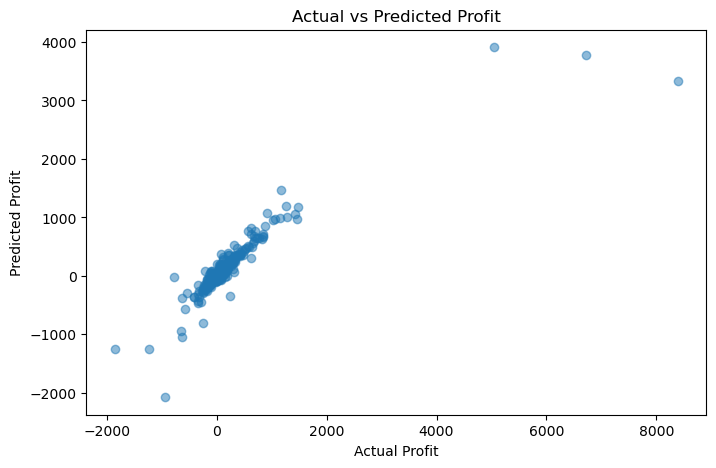

In [329]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.5
)

plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs Predicted Profit")

plt.show()

39.Residual Analysis

In [332]:
residuals = y_test - y_pred_rf

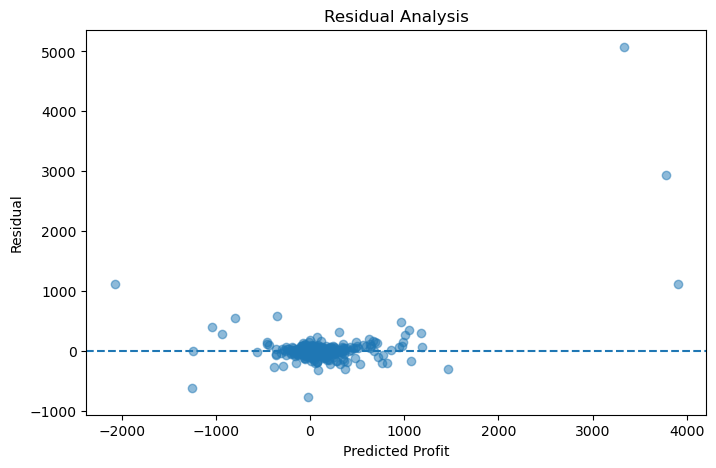

In [334]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_pred_rf,
    residuals,
    alpha=0.5
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Profit")
plt.ylabel("Residual")
plt.title("Residual Analysis")

plt.show()

40.Cross-Validation

In [337]:
from sklearn.model_selection import cross_val_score

In [339]:
cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Cross-validation R² scores:", cv_scores)
print("Mean CV R²:", cv_scores.mean())

Cross-validation R² scores: [0.0061952  0.86939034 0.78323673 0.74431849 0.82261687]
Mean CV R²: 0.645151526079055


41. Feature Importance

In [341]:
rf = rf_model.named_steps["model"]

In [344]:
preprocessor_fitted = rf_model.named_steps["preprocessor"]

In [346]:
feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

In [348]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

In [350]:
feature_importance.head(15)

,Feature,Importance
0,num__Sales,0.582490
2,num__Discount,0.272954
1,num__Quantity,0.019818
3,num__Shipping Days,0.014986
22,cat__Sub-Category_Supplies,0.014752
10,cat__Sub-Category_Binders,0.014156
13,cat__Sub-Category_Copiers,0.008697
18,cat__Sub-Category_Machines,0.007376
26,cat__Region_South,0.007353
27,cat__Region_West,0.006382


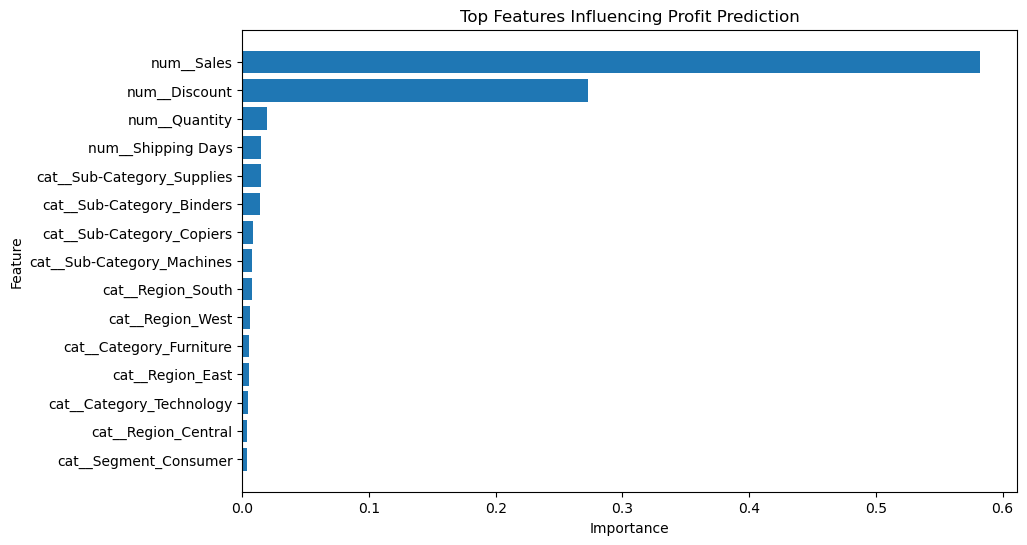

In [352]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Features Influencing Profit Prediction")

plt.gca().invert_yaxis()

plt.show()

In [354]:
print("Linear Regression")
print("-----------------")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

print("\nRandom Forest")
print("-----------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Linear Regression
-----------------
MAE : 61.68239238319444
RMSE: 214.06992635436313
R²  : 0.4892674810421861

Random Forest
-----------------
MAE : 20.477544491195687
RMSE: 142.97983931897414
R²  : 0.7721590405372517
